# Study of Recurrent Neural Network (RNN)

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
print(f'Import PyTorch V{torch.__version__}')

dev = torch.device(type='cuda') if torch.cuda.is_available() else \
      torch.device(type='cpu')
print(f'Use device {dev}')

Import PyTorch V2.1.1
Use device cuda


In [2]:
from d2l import torch as d2l
d2l.use_svg_display()

## Working with sequences

In [3]:
class Data(d2l.DataModule):
    def __init__(self, batch_size=16, T=1000, num_train=600, tau=4):
        self.save_hyperparameters()
        self.time = torch.arange(1, T + 1, dtype=torch.float32)
        self.x = torch.sin(0.01 * self.time) + torch.randn(T) * 0.2

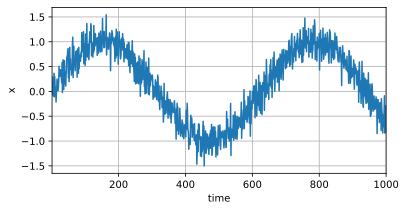

In [4]:
data = Data()
d2l.plot(data.time, data.x, 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

In [5]:
@d2l.add_to_class(Data)
def get_dataloader(self, train):
    features = [self.x[i : self.T-self.tau+i] for i in range(self.tau)]
    self.features = torch.stack(features, 1)
    self.labels = self.x[self.tau:].reshape((-1, 1))
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader([self.features, self.labels], train, i)

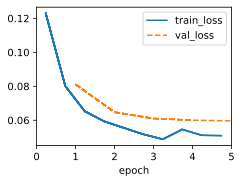

In [6]:
model = d2l.LinearRegression(lr=0.01)
trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data)

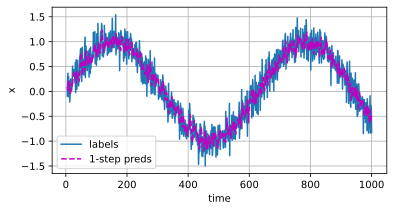

In [7]:
onestep_preds = model(data.features).detach().numpy()
d2l.plot(data.time[data.tau:], [data.labels, onestep_preds], 'time', 'x',
         legend=['labels', '1-step preds'], figsize=(6, 3))

## Converting Raw Text into Sequence Data

In [8]:
import collections
import random
import re

In [9]:
class TimeMachine(d2l.DataModule): #@save
    """The Time Machine dataset."""
    def _download(self):
        fname = d2l.download(d2l.DATA_URL + 'timemachine.txt', self.root,
                             '090b5e7e70c295757f55df93cb0a180b9691891a')
        with open(fname) as f:
            return f.read()

In [10]:
print('Prepare time machine text material')
data = TimeMachine()
raw_text = data._download()
raw_text[:60]

Prepare time machine text material


'The Time Machine, by H. G. Wells [1898]\n\n\n\n\nI\n\n\nThe Time Tra'

In [11]:
class Vocab: #@save
    """Vocabulary for text."""
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        # Flatten a 2D list if needed
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        # The list of unique tokens
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [ token for token, freq in self.token_freqs if freq >= min_freq])))
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]

    @property
    def unk(self): # Index for the unknown token
        return self.token_to_idx['<unk>']

In [12]:
@d2l.add_to_class(TimeMachine)  #@save
def _preprocess(self, text):
    return re.sub('[^A-Za-z]+', ' ', text).lower()

@d2l.add_to_class(TimeMachine)  #@save
def _tokenize(self, text):
    return list(text)

@d2l.add_to_class(TimeMachine)  #@save
def build(self, raw_text, vocab=None):
    tokens = self._tokenize(self._preprocess(raw_text))
    if vocab is None:
        vocab = Vocab(tokens)
    corpus = [vocab[token] for token in tokens]
    return corpus, vocab

In [13]:
corpus, vocab = data.build(raw_text)
len(corpus), len(vocab)

(173428, 28)

In [14]:
corpus[:10]

[21, 9, 6, 0, 21, 10, 14, 6, 0, 14]

In [15]:
','.join(vocab.idx_to_token)

' ,<unk>,a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y,z'

In [16]:
text = data._preprocess(raw_text)
text[:20]

'the time machine by '

In [17]:
words = text.split(' ')
word_vocab = Vocab(words)
word_vocab.token_freqs[:5]

[('the', 2261), ('i', 1267), ('and', 1245), ('of', 1155), ('a', 816)]

In [18]:
bigram_tokens = ['--'.join(pair) for pair in zip(words[:-1], words[1:])]
bigram_vocab = Vocab(bigram_tokens)
bigram_vocab.token_freqs[:5]

[('of--the', 309),
 ('in--the', 169),
 ('i--had', 130),
 ('i--was', 112),
 ('and--the', 109)]

In [19]:
trigram_tokens = ['--'.join(triple) for triple in zip( words[:-2], words[1:-1], words[2:])]
trigram_vocab = Vocab(trigram_tokens)
trigram_vocab.token_freqs[:5]

[('the--time--traveller', 59),
 ('the--time--machine', 30),
 ('the--medical--man', 24),
 ('it--seemed--to', 16),
 ('it--was--a', 15)]

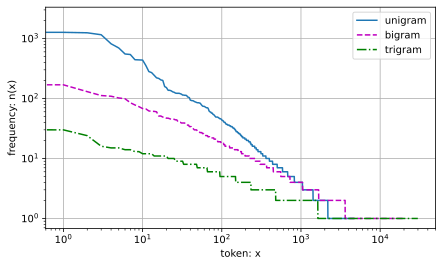

In [20]:
word_freqs = [freq for _, freq in word_vocab.token_freqs]
bigram_freqs = [freq for _, freq in bigram_vocab.token_freqs]
trigram_freqs = [freq for _, freq in trigram_vocab.token_freqs]
d2l.plot([word_freqs, bigram_freqs, trigram_freqs], xlabel='token: x',
         ylabel='frequency: n(x)', xscale='log', yscale='log',
         legend=['unigram', 'bigram', 'trigram'], figsize=(7, 4))